# Práctica 13: Imágenes y animaciones

En esta práctica se revisaran algunas funciones de MATLAB® que permiten la manipulación de archivos que contienen imágenes, para su visualización y análisis como variables. Además de su despliegue en figuras nativas, es decir, como elementos gráficos, es posible almacenar los componentes básicos en espacios de memoria en un formato de arreglos o matrices, lo cual permite la descomposición de las imágenes en los componentes de colores básicos rojo, azul y verde, además de su manipulación usando muchas de las importantes herramientas del álgebra lineal. En esta práctica se tratará con los imágenes representadas usando los colores primario Rojo, Verde y Azul, que son la base del estandard o formato RGB para la representación de imágenes en dispositivos electrónicos como lo son las computadoras y las pantallas de los sistemas inteligentes.

La unidad básica para la representación de las imágenes es el pixel, un pixel es entendido como una célula de una imágen. Una imágen se compone de miles o millones de estas unidades fundamnetales que a su vez se conforman de los tres colores primarios rojo, verde y azul, dado que la combinación de estos tres colores permite generar una amplia gama de colores y así representar imágenes. A cada pixel se le asignan tres variables que representan la intensidad de rojo, verde y azul en la imagen en ese punto en específico, en un rango de 0 a 255.

El comando básico para leer una imagen y almacenar su información pixel por pixel es `imread()` las impagenes se pueden leer desde archivos que se encuentren en la carpeta de trabajo, indicando la ruta al archivo si se encuentra en el disco duro en algún directorio diferente e inlcluso desde internet indicado la dirección completa.

In [3]:
clear 
close all
clc
[A]= imread("https://raw.githubusercontent.com/LuisGerardo2204/Archivos_de_datos/refs/heads/main/juguete.png"); % Lectura y almacenamiento de una imagen en el arreglo A
whos A % Se muestran las características del arreglo A

  Name        Size                 Bytes  Class    Attributes

  A         659x621x3            1227717  uint8              



Como puede observarse, el arreglo A contiene 3 matrices de dimensiones 659x621. La primera matriz, es decir el elemento `A(:,:,1)` contiene la intensidad del color rojo de cada pixel, la matriz  `A(:,:,2)` la intensidad del tono verde en cada pixel y finalmente la matriz `A(:,:,3)` la intensidad del color azul por pixel.

Para mostrar la imagen descargada o almacenada en el arreglo A se usa el comando `imshow()`

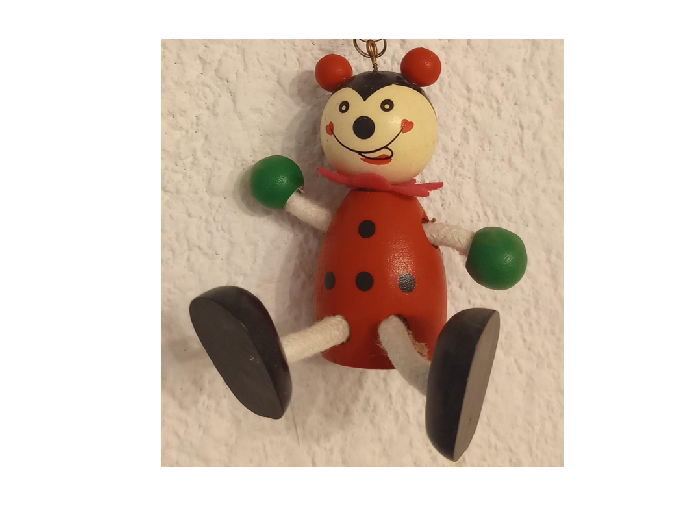

In [4]:
figure %Se inicializa una nueva figura
imshow(A) %Se despliega la imagen en la figura antes inicializada

Es posible visualizar la imagen en una figura con el formato de las gráficas con escala numérica, con la particularidad de que en los ejes se muestran las dimensiones en pixeles de la imagen:

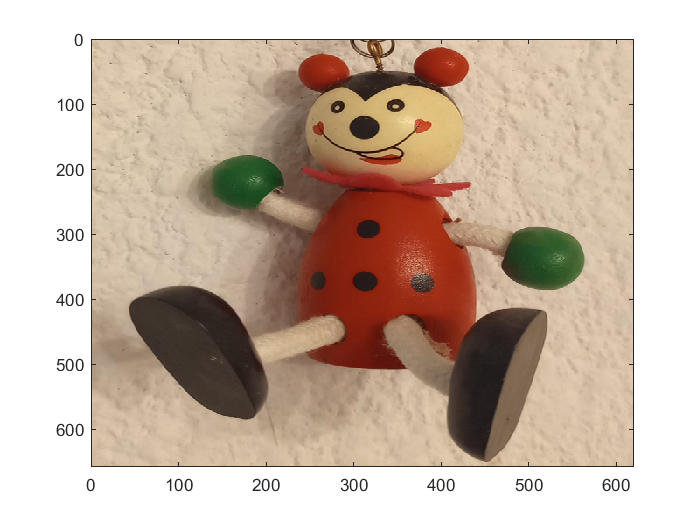

In [6]:
figure
image([0 0],[0 0],A)%Se establece el origen como el punto incial para desplegar la imagen 
% En los arreglos [x1 x2],[y1 y2]

La imagen se visualiza al combinar los tres colores primarios en cada pixel con las intesidades indicadas en cada
uno de los elementos de la matriz A. Por ejemplo los componentes rojo, azul y verde en el pixel $200,200$ de laimagen con la que se está trabajando son:

In [7]:
pixel_200_200=[A(200,200,1) A(200,200,2) A(200,200,3)]

pixel_200_200 = 1×3 uint8
   32   79   38

El valor máximo de la intensidad para cada color rojo verde o azul es de 255. Las siguientes líneas de código ilustran la extracción de los colores en tres pixeles específicos:

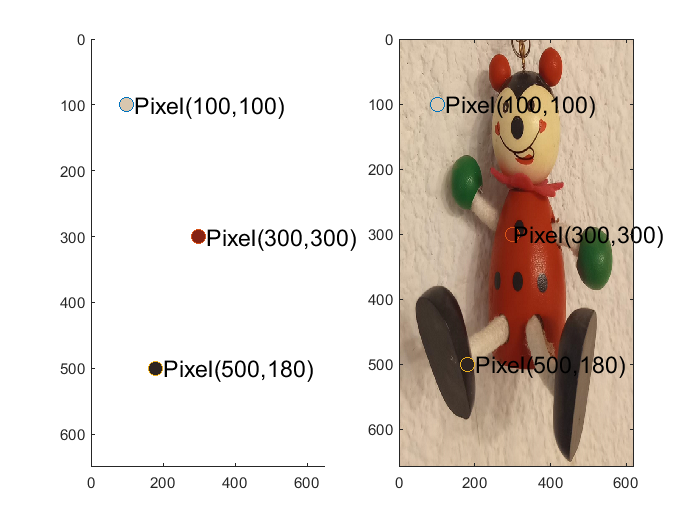

In [8]:
close all
figure
subplot(1,2,1)
hold on
scatter(100,100,75,"MarkerFaceColor",[A(100,100,1) A(100,100,2) A(100,100,3)])
txt = "Pixel(100,100)";
text(120,100,txt,'FontSize',14)
scatter(300,300,75,"MarkerFaceColor",[A(300,300,1) A(300,300,2) A(300,300,3)])
txt = "Pixel(300,300)";
text(320,300,txt,'FontSize',14)
txt = "Pixel(500,180)";
text(200,500,txt,'FontSize',14)
scatter(180,500,75,"MarkerFaceColor",[A(500,180,1) A(500,180,2) A(500,180,3)])
axis([0 650,0,650])
set(gca,'Ydir','reverse')

subplot(1,2,2)
image([0 0],[0 0],A)%Se establece el origen como el punto incial para desplegar la imagen 
% En los arreglos [x1 x2],[y1 y2]
hold on
scatter(100,100,75,"MarkerFaceColor",[A(100,100,1) A(100,100,2) A(100,100,3)])
txt = "Pixel(100,100)";
text(120,100,txt,'FontSize',14)
scatter(300,300,75,"MarkerFaceColor",[A(300,300,1) A(300,300,2) A(300,300,3)])
txt = "Pixel(300,300)";
text(300,300,txt,'FontSize',14)
scatter(180,500,75,"MarkerFaceColor",[A(500,180,1) A(500,180,2) A(500,180,3)])
txt = "Pixel(500,180)";
text(200,500,txt,'FontSize',14)

Con base en lo anterior, es posible asignar una tonalidad específica a un pixel o grupo de pixeles, por ejemplo, para manipular el pixel 500,180 y asignarle un color blanco es necesario asignarle el valor de 255 a cada uno de los componentes R,G y B de esa localidad en específico.

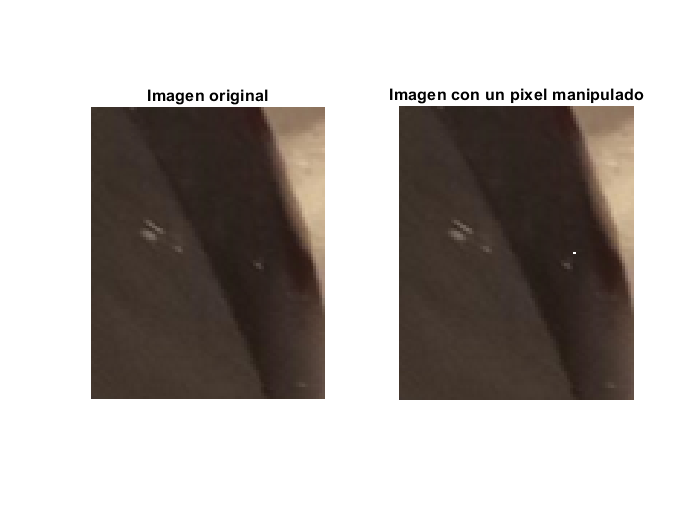

In [9]:
figure
subplot(1,2,1)
imshow(cat(3,A(450:550,120:200,1),A(450:550,120:200,2),A(450:550,120:200,3)))% Ajuste para despliegue de la imagen
title("Imagen original")
A(500,180,1)=255;
A(500,180,2)=255;%Manipulación del pixel (500,180)
A(500,180,3)=255;
subplot(1,2,2)
imshow(cat(3,A(450:550,120:200,1),A(450:550,120:200,2),A(450:550,120:200,3)))% Ajuste para despliegue de la imagen
title("Imagen con un pixel manipulado")

## Operaciones de edición de forma de imágenes

Las imágenes se pueden rotar, reflejar y presentar de forma invertida usando los comandos ´imrotate(I,grados)´, ´flipdim(I,2)´ y ´flipdim(I,1)´. Adicionalmente, las imágenes se pueden ampliar y reducir usando el comando ´imresize(I,factor)´. Por ejemplo, el resultado de aplicar operaciones tipo espejo y reflejo se ilustran con el siguiente código:

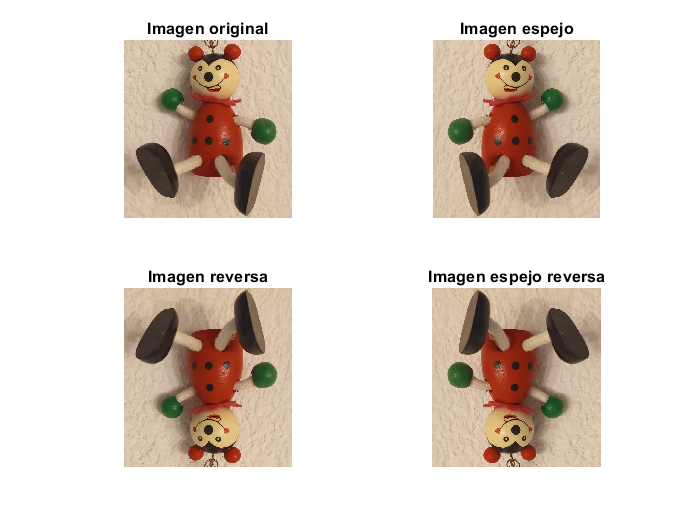

In [7]:
imagen_espejo=flipdim(A,2);%Se calcula el reflejo de la imagen y se almacena en un arreglo
imagen_reversa=flipdim(A,1);%Se calcula la reversa de la imagen y se almacena en un arreglo
imagen_espejo_reversa=flipdim(imagen_reversa,2);%Se hace un reflejo de la imagen invertida

figure
subplot(2,2,1)
imshow(A)
title("Imagen original")
subplot(2,2,2)
imshow(imagen_espejo)
title("Imagen espejo")
subplot(2,2,3)
imshow(imagen_reversa)
title("Imagen reversa")
subplot(2,2,4)
imshow(imagen_espejo_reversa)
title("Imagen espejo reversa")



Las componentes rojo, verde y azul se encuentran en las matrices individuales del arreglo.

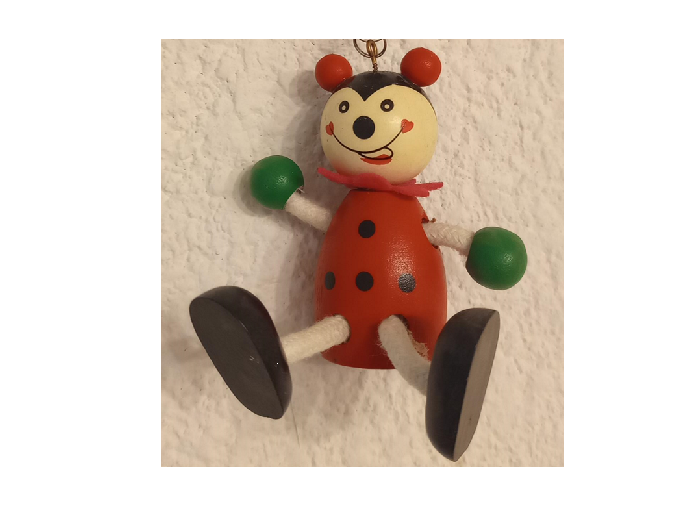

In [8]:
Rojo = A(:,:,1); 
Verde = A(:,:,2); %Descomposición de la intensidad de rojo, verde y azul de la imágen original
Azul = A(:,:,3);

figure
imshow(cat(3, Rojo, Verde, Azul))% Se despliega la imagen original usando sus componentes por separado

Para intensificar el azul en la figura original se puede sumar una constante a la matriz con los datos de la intensidad de ese tono primario:

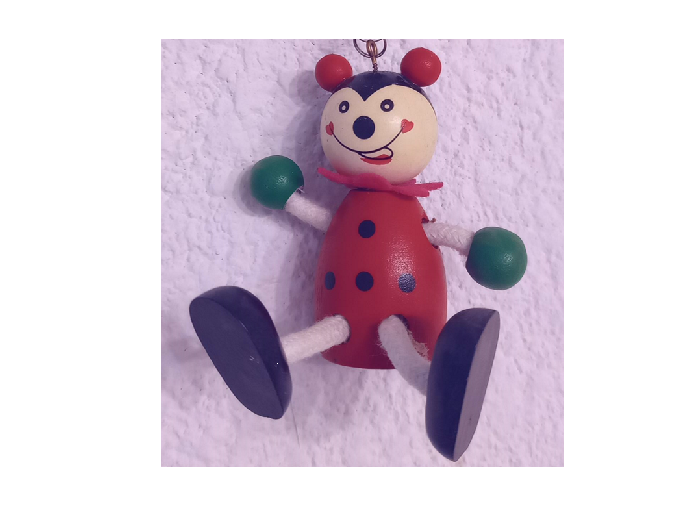

In [9]:

figure
imshow(cat(3, Rojo, Verde, Azul+50))% Se despliega la imagen original usando sus componentes por separado
%con el color azul intensificado

La rotación de la imagen original con un ángulo de 60 grados se usa el comando `imrotate()` con la especificación bilineal:

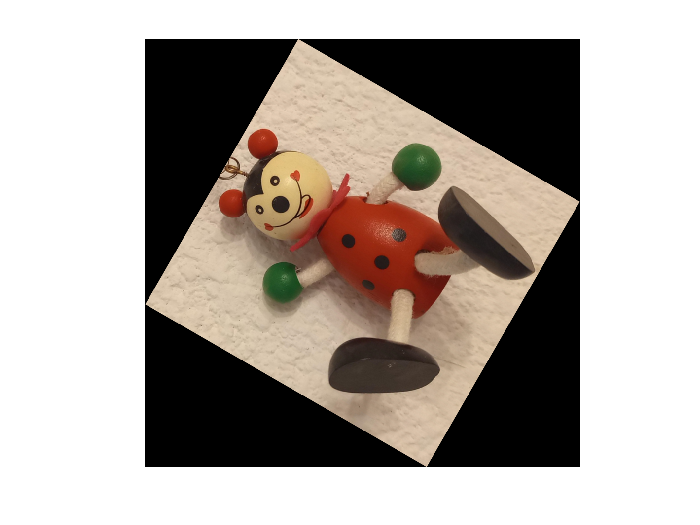

In [10]:
imagen_rotada=imrotate(A,60,"Bilinear");
figure
imshow(imagen_rotada)

Las operaciones de amplificación y reducción se muestran en las siguientes líneas

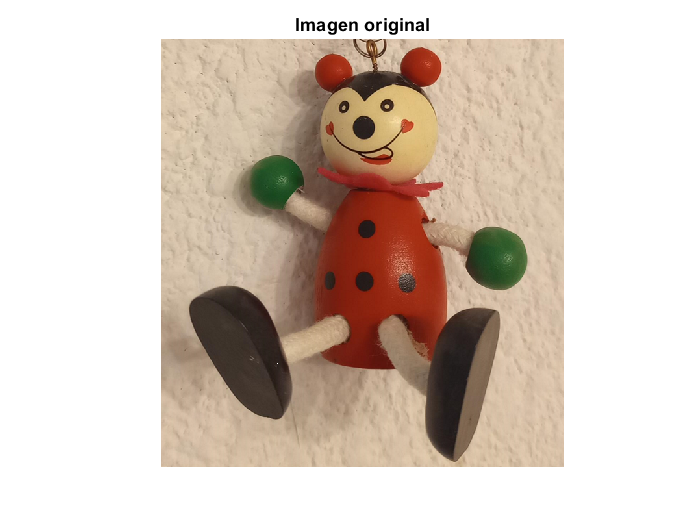

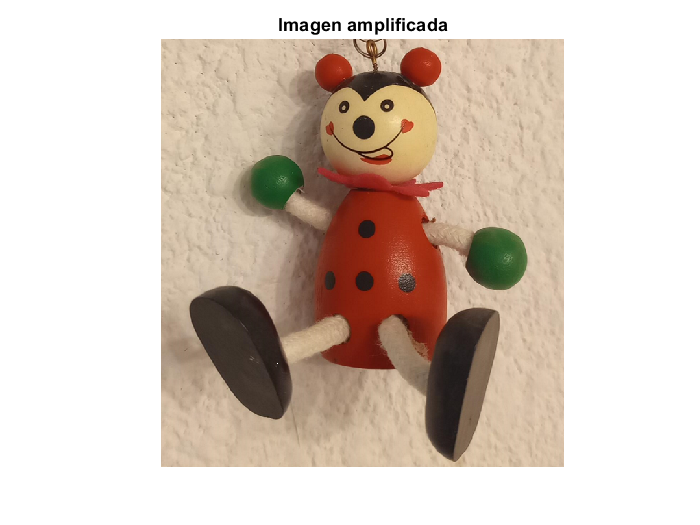

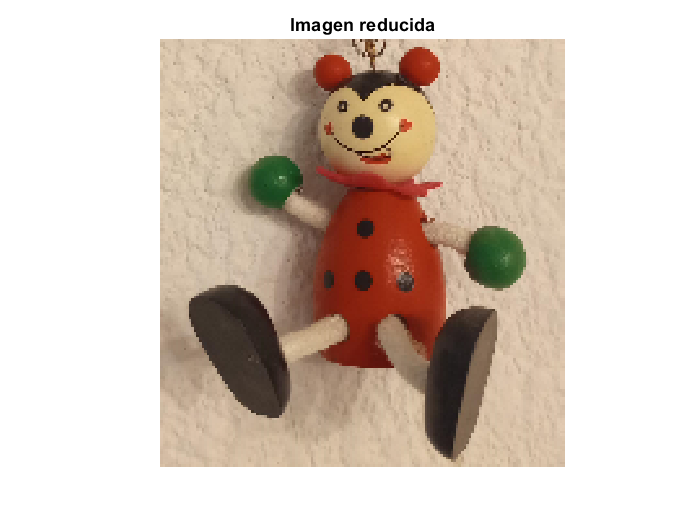

In [11]:
imagen_amplificada=imresize(A,20,"nearest");
imagen_reducida=imresize(A,0.25,"nearest");
figure
imshow(A)
title("Imagen original")
figure
imshow(imagen_amplificada)
title("Imagen amplificada")
figure
imshow(imagen_reducida)
title("Imagen reducida")

In [12]:
disp("Dimensiones de la imagen original:")
whos A
disp("Dimensiones de la imagen ampliada:")
whos imagen_amplificada
disp("Dimensiones de la reducida:")
whos imagen_reducida

Dimensiones de la imagen original:
  Name        Size                 Bytes  Class    Attributes

  A         659x621x3            1227717  uint8              

Dimensiones de la imagen ampliada:
  Name                        Size                     Bytes  Class    Attributes

  imagen_amplificada      13180x12420x3            491086800  uint8              

Dimensiones de la reducida:
  Name                   Size               Bytes  Class    Attributes

  imagen_reducida      165x156x3            77220  uint8              



Es posible modificar el contraste de las imájenes usando el comando `imadjust(I,[minR minG minB;maxR maxG maxB],[])`

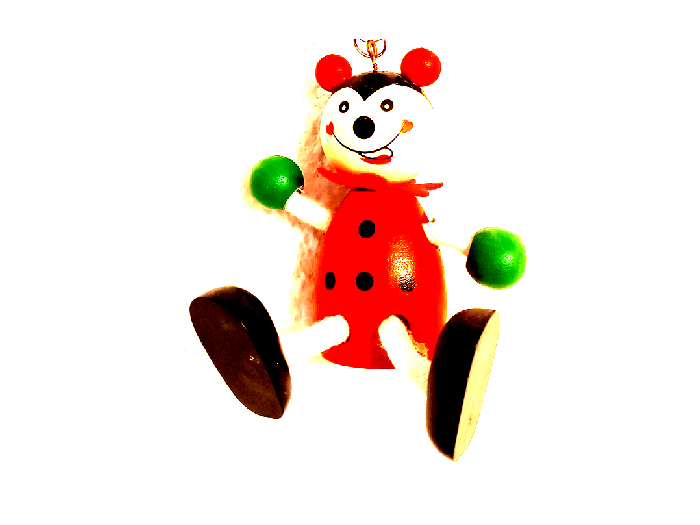

In [13]:
imagen_ajustada_RGB=imadjust(A, [0.2 0.2 0.2; 0.4 0.4 0.4],[]);
imshow(imagen_ajustada_RGB)

### Descomposicion de las imágenes en componentes HSV

Una forma diferente de descomponer las imágenes es el formato HSV (Hue,Saturation,Value) que corresponden en español a los términos de matiz, saturación y brillo. El comando para la conversión de una imágen codificada en RGB a una codificada en formato HSV es `rgb2hsv(I)`. Para mas información se puede consultar:

https://medium.com/@DIYCoding/color-models-in-image-processing-understanding-rgb-and-hsv-for-computer-vision-a629641cdc40

La representación en formato HSV de la imagen de ejemplo se muestra con las siguientes líneas de código:

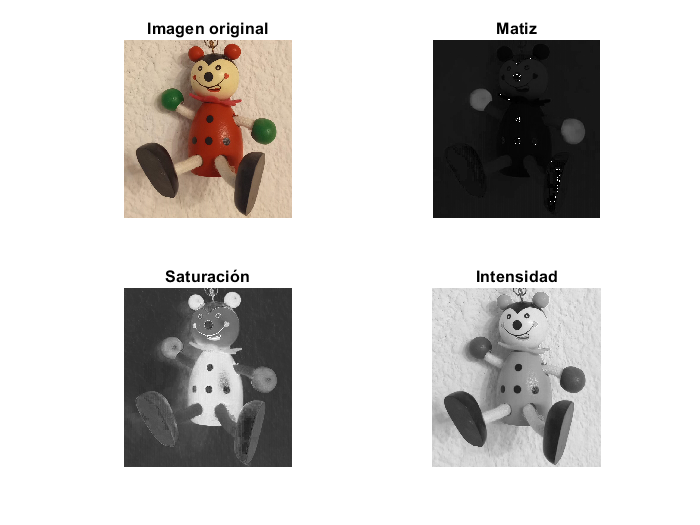

In [14]:
HSI=rgb2hsv(A);
figure
subplot(2,2,1)
imshow(A)
title("Imagen original")
subplot(2,2,2)
imshow(HSI(:,:,1))
title("Matiz")
subplot(2,2,3)
imshow(HSI(:,:,2))
title("Saturación")
subplot(2,2,4)
imshow(HSI(:,:,3))
title("Intensidad")


Para cambiar el nivel de saturación de la imagen de ejemplo se manipula la matriz S del arreglo HSV creado:

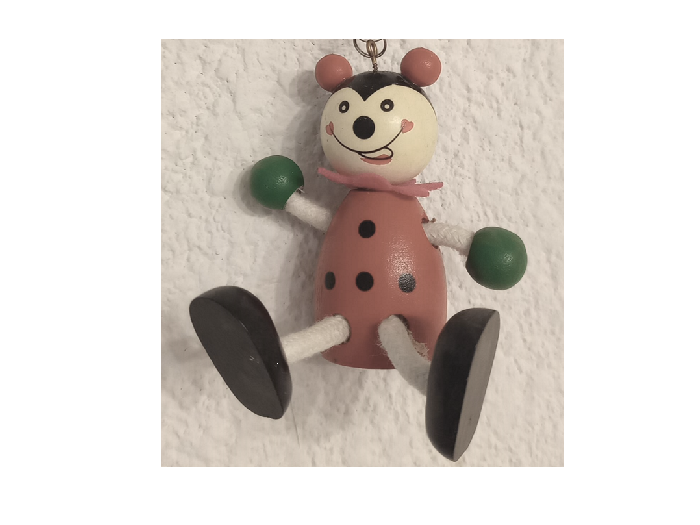

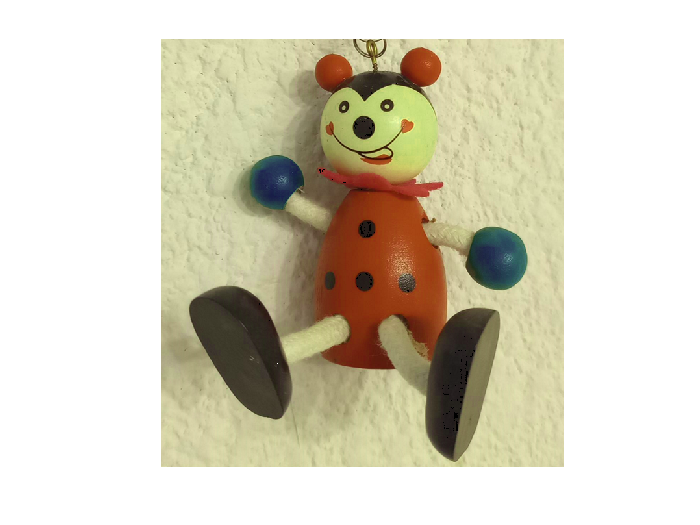

In [15]:
figure
[H,S,V] = imsplit(HSI);%Se divide la matriz convertida 
factor = 0.5;
S_saturada = S*factor; % Se afecta a la matriz de saturación
HSV_saturada = cat(3,H,S_saturada,V);
RGB_saturada = hsv2rgb(HSV_saturada);
imshow(RGB_saturada)

figure
[H,S,V] = imsplit(HSI);%Se divide la matriz convertida 
factor = 1.8;
H_saturada = H*factor; % Se afecta a la matriz de saturación
HSV_saturada = cat(3,H_saturada,S,V);
RGB_saturada = hsv2rgb(HSV_saturada);
imshow(RGB_saturada)

## Conversión a escala de grises

Una imagen a color se puede convertir a su equivalente en escala de grises usando el comando `rgb2gray()` y tambien aplicando algunas operaciones a las matrices de valores rojo, verde y azul como se muestra en las siguientes líneas: 

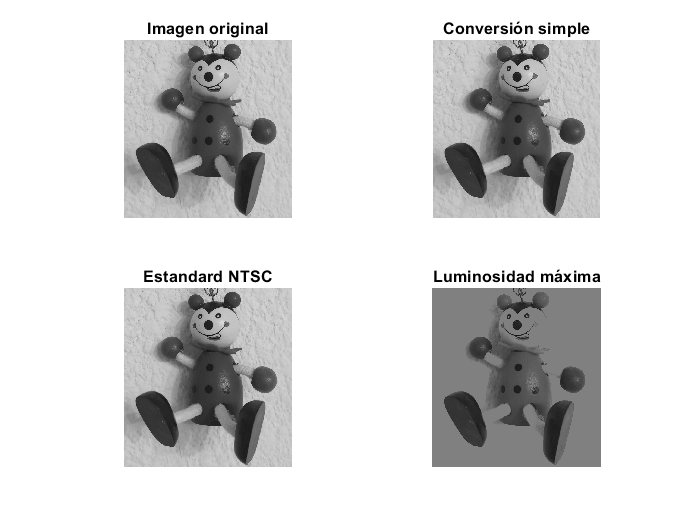

In [16]:
RGB_grises=rgb2gray(A); %Conversión de la imágen original a escala de grises
RGB_grises2=0.299*Rojo+0.587*Verde+0.114*Azul;
RGB_grises3=0.21*Rojo+0.72*Verde+0.07*Azul; %Tres técnicas diferentes de conversión a grises
RGB_grises4=(max(A,[],3)+min(A,[],3))/2;
figure
subplot(2,2,1)
imshow(RGB_grises)
title("Imagen original")
subplot(2,2,2)
imshow(RGB_grises2)
title("Conversión simple")
subplot(2,2,3)
imshow(RGB_grises3)
title("Estandard NTSC")
subplot(2,2,4)
imshow(RGB_grises4)
title("Luminosidad máxima")


Una alternativa más es representar a las imágnes en el formato de intensidades de color en gráficas tridimencionales:

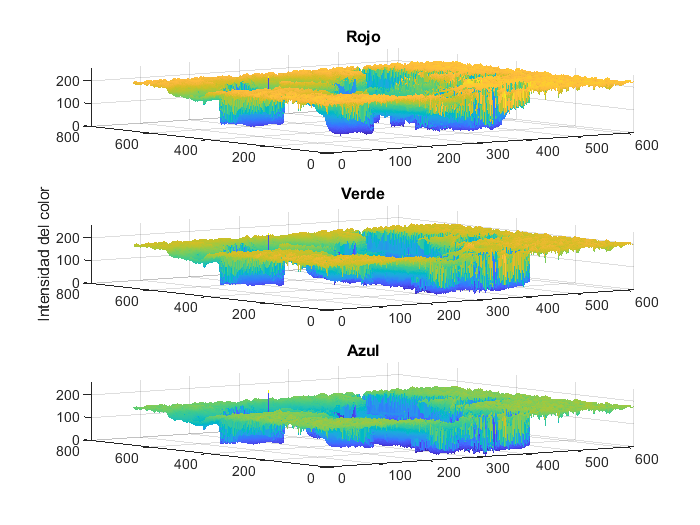

In [17]:

[r,c,j]=size(A);% Se actualiza el tamaño de la imagen
 
figure
subplot(3,1,1)
surf(1:c,1:r,Rojo,'EdgeColor','none'); 
title("Rojo")
view(3)
subplot(3,1,2)   % Se grafican en formato de intensidad los colores
surf(1:c,1:r,Verde,'EdgeColor','none'); 
zlabel('Intensidad del color')
view(3)
title("Verde")
subplot(3,1,3)
surf(1:c,1:r,Azul,'EdgeColor','none'); 
title("Azul")
view(3)



## Animación de funciones

Es posible realizar la animación de funciones en las gráficas generadas con MATLAB®, con el fin de integrar dinámica visual a los resultados numéricos que representan las gráficas de las funciones. Una de las formas de generar animaciones es generar una gráfica que se atualice cada cierto intervalo. Los siguientes ejemplos muestran la forma de generar animaciones de dos casos clásicos en física, el movimiento rectilíneo y el oscilador armónico.

### Movimiento rectilíneo

El movimiento rectilíneo es aquel que se puede representar en el plano usando una sola coordenada. Esta coordenada se modela como una función del tiempo y describe el movimiento de una partícula en términos de su posición respecto de un marco de referencia fíjo y su velocidad y aceleración definidas como:

* $x(t)=$ posición en metros.
* $v(t)=\frac{dx(t)}{dt}=$velocidad en $[m/s]$.
* $a(t)=\frac{dx^2(t)}{dt^2}=$ aceleración en $[m/s^2]$.

El siguiente ejemplo permite generar la animación de un movimiento rectilíneo que describe una trayectoria oscilatoria en el eje $x$, descrito por la expresión:

$$
x(t)=4.5sen(2t)~~[m]
$$

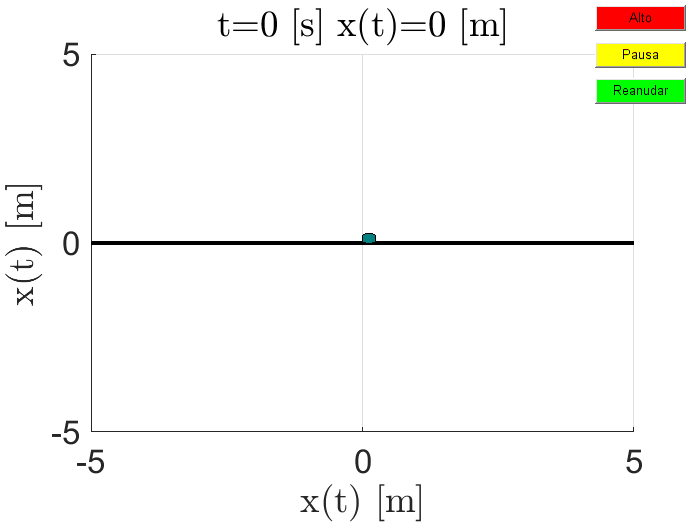

In [18]:
clear 
close all
clc

% Creación del vector de tiempo
t=0:0.001:6;

%Se programa la expresión a animar
xt=4.5*sin(2*t);

uno=figure;
grid


axis([-5 5,-5 5])

%Se generan botones de control de animación especificndo su texto posición y color de fondo
  handle=uicontrol('style','pushbutton','units','normal','backgroundcolor','red','position', ...
            [0.85 .94 .13 .05],'String','Alto','callback','global stopstop;stopstop=1;'); 
  handle2=uicontrol('style','pushbutton','units','normal','backgroundcolor','yellow','position', ...
            [0.85 .87 .13 .05],'String','Pausa','callback','global ppause;ppause=1;');
  handle3=uicontrol('style','pushbutton','units','normal','backgroundcolor','green','position', ...
            [0.85 .8 .13 .05],'String','Reanudar','callback','global ppause;ppause=0;');

 % Se da formato al texto de los ejes de las gráficas           
set(gca,'defaulttextinterpreter','latex')
  
   set(get(gca,'XLabel'),'String','x(t) [m]',...
                    'FontName','Arial',...
                    'FontAngle','normal',...
                    'FontSize',20)
% 
 set(get(gca,'YLabel'),'String','x(t) [m]',...
                     'FontName','Arial',...
                     'FontAngle','normal',...
                     'FontSize',20)

 
set(gca,'fontsize',20);
set(gca,'fontname','Arial','FontWeight','normal');  

global stopstop ppause;
ppause=0;
i=1;
stopstop =0;
% La animación se repetirá para cada valor de la función x(t) en cada instante de tiempo 
  while( i<5000&&stopstop==0)
    
     cla
     
     title(strcat('t= ',num2str((i-1)*0.001),' [s]','    x(t)= ',num2str(xt(i)),' [m]'))
     hold on
     plot([-5:0.001:5],0*[-5:0.001:5],'k -','LineWidth',2)%Se grafica la paríticula
     plot(t(1:i),xt(1:i),'b -','LineWidth',2) %Actualización de la posición de la partícula
    rectangle('Position',[xt(i) 0.0 0.24 0.24],'FaceColor',[0 .5 .5],'Curvature',0.5)% Se dibuja la partícula
    pause(0.001)
   
                while ppause==1
                    pause(.001)%Acción del botón de pausa
                  
                end
        i=i+10;       
       cla %pausa para animación
                  
    end
    close(uno)



### Sistema oscilador armónico.

Un sistema masa-resorte-amortiguador se considera como un oscilador armónico y se modela matemáticamente usando la ecuación diferencial:

```{math}
:label: modelo1
\begin{equation}
  m\frac{d^2y(t)}{dt^2}+b\frac{dy(t)}{dt}+ky(t)=f(t)
	\end{equation}
```
Donde $y(t)$ es la solución de la ecuación diferencial {eq}`modelo1` y representa al desplazamiento en metros de la masa $m$ respecto del punto de equilibrio, $m$ es la masa en $[kg]$, $b$ la constante de amortiguador con unidades $[Ns/m]$ y $k$ en unidades $[N/m]$. además $f(t)$ es la fuerza externa. En una práctica posterior se retomará este modelo para hacer simulaciones en el entorno gráfico simulink®.

La solución general para el caso de vibraciones libres, es decir, cuando $f(t)=0$ y por lo menos alguna de las condiciones iniciales de posición $y(0)$ en $[m]$ o velocidad $v(0)$ en $[m/s]$ es 

```{math}
:label: solgen
\begin{equation}
  y(t)=e^{-\frac{b}{2m}t}(y(0)cos(\omega_{d}t)+\beta sen(\omega_{d}t))
	\end{equation}
```
donde $\omega_d$ y $\beta$ son la frecuencia natural mortiguada y $\beta$ una constante dadas por: 

$$
\omega_d=\sqrt{\frac{k}{m}-\frac{b^2}{4m^2}},~~~~\beta=\frac{mv(0)+by(0)}{m\omega_d}
$$

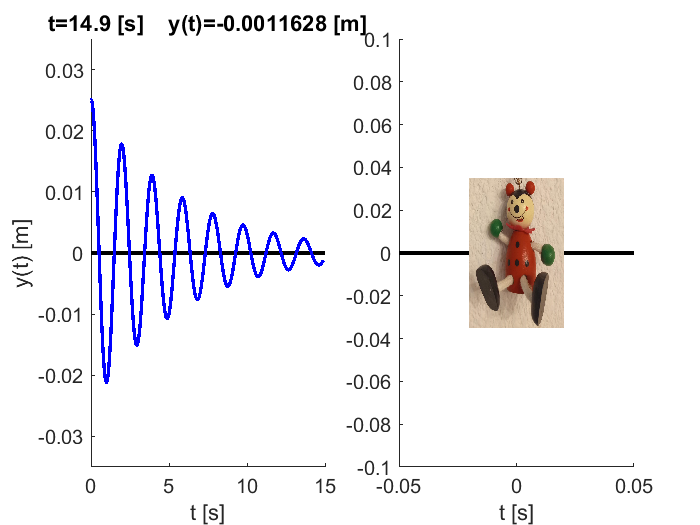

In [4]:
clear 
close all
clc
%Se lee la imagen del juguete a animar como oscilador armónico
A=imread("https://raw.githubusercontent.com/LuisGerardo2204/Archivos_de_datos/refs/heads/main/juguete.png");
% Parámetros del sistema masa-resorte-amortiguador
m=0.43;
b=0.15;
k=4.5; 
%condiciones iniciales de posición y velocidad
y0=0.025;
dy0=0.0;
% Cálculo de la frecuencia natural amortiguada
wd=sqrt(k/m-b^2/(4*m^2));
% Constante de la solución omogénea
a=(m*dy0+b*y0)/(m*wd);

%vector de tiempo
t=0:0.001:15;
% Función x(t)
yt=exp((-b/(2*m)).*t).*(y0*cos(wd.*t)+a*sin(wd.*t));


dos=figure;

i=1;
% La animación se repetirá para cada valor de la función x(t) en cada instante de tiempo 
while((i<max(t)*1000))
    
     cla
    
     subplot(1,2,1)
     hold on
       plot([-max(t):0.001:max(t)],0*[-max(t):0.001:max(t)],'k -','LineWidth',2)
      plot(t(1:i),yt(1:i),'b -','LineWidth',2)
      axis([0 max(t),-0.035 0.035])
      
  % Se da formato al texto de los ejes de las gráficas    
      set(get(gca,'XLabel'),'String','t [s]',...
                    'FontName','Arial',...
                    'FontAngle','normal',...
                    'FontSize',12)
% 
     set(get(gca,'YLabel'),'String','y(t) [m]',...
                     'FontName','Arial',...
                     'FontAngle','normal',...
                     'FontSize',12)

    set(gca,'fontsize',12);
    set(gca,'fontname','Arial','FontWeight','normal');  
    title(strcat('t= ',num2str((i-1)*0.001),' [s]','    y(t)= ',num2str(yt(i)),' [m]'))
    
   % Se da formato al texto de los ejes de las gráficas    
       
    subplot(1,2,2)
     hold on
     plot([-max(t):0.001:max(t)],0*[-max(t):0.001:max(t)],'k -','LineWidth',2)
     image([-0.02 0.02],[yt(i)+0.035 yt(i)-0.035],A); %Se inserta la imagen a animar en la gráfica
     axis([-0.05 0.05,-0.1 0.1]) % Ajuste de coordenadas para visualización
   %Se da formato y tamaño de letra a la gráfica animada
     set(get(gca,'XLabel'),'String','t [s]',...
                    'FontName','Arial',...
                    'FontAngle','normal',...
                    'FontSize',12)
     set(gca,'fontsize',12);
     set(gca,'fontname','Arial','FontWeight','normal');  
                
   i=i+100;       
   pause(0.01)% pausa para animación
   cla               
end     
% Se grafica la imágen en el punto de equilibrio original al terminar la animación
subplot(1,2,2)
hold on
plot([-max(t):0.001:max(t)],0*[-max(t):0.001:max(t)],'k -','LineWidth',2)
image([-0.02 0.02],[0.035 -0.035],A); 
     axis([-0.05 0.05,-0.1 0.1])
set(get(gca,'XLabel'),'String','t [s]',...
                    'FontName','Arial',...
                    'FontAngle','normal',...
                    'FontSize',12)
set(gca,'fontsize',12);
set(gca,'fontname','Arial','FontWeight','normal');  

## Ejercicio de la práctica 13

1.- Descargue o lea desde la ruta las siguientes imágenes:

https://raw.githubusercontent.com/LuisGerardo2204/Archivos_de_datos/refs/heads/main/flores.JPG
https://raw.githubusercontent.com/LuisGerardo2204/Archivos_de_datos/refs/heads/main/cedral.jpg

Realice las siguientes operaciones con las dos imágenes:

a) En una figura muestre la imagen original, la imagen en escala de grises, la imagen invertida y la imagen escalada al 25% de su tamaño original.

b) En otra figura muestre la imagen original y su versión en el formato HSV con el factor 0.8 aplicado a la matriz de color o matiz.

c) En una tercer figura muestre la imagen original y la figura con las siguientes transformaciones:

$$
Y= 0.3R+0.6G+0.114B,~~~~I=-0.5R-0,3G+0.4B,~~~~~Q=0.7R-0.52G-0.12B
$$

donde $R$ es la matriz componente rojo, $B$ es la matriz componente azul y $G$ es la matriz componente verde. Use el comando `imshow(cat(3,Y,I,Q))` para mostrar la imagen transformada.

2.- Realice la animación de la gráfica $y(t)$ para un sistema masa-resorte con condiciones iniciales $y(0)=0.015~[m]$, velocidad inicial $v(0)=0~[m/s]$, masa $m=0.5~[kg]$ y constante de rigidez $k=300~[N/m]$. Considere que la ecuaciones {eq}`solgen` para construir la ecuación para simular el caso particular que se plantea.

3.- Realice la animación de la gráfica de uno de los casos del tiro parabólico del ejercicio 2 de la Práctica 9. 
